# =============================================================================
# PROJETO: MNIST Digit Classifier - Análise Preditiva Multiclasse
# AUTOR: Guillermo Jose Salas Avila
# DATA: 10/09/2026
# DESCRIÇÃO: Pipeline completo de Machine Learning para classificação de 
#            dígitos manuscritos usando o dataset MNIST.
#            Modelos: Random Forest, KNN e MLP (scikit-learn)
# =============================================================================

# 0- Importação de bibliotecas.

In [1]:
# -----------------------------------------------------------------------------
# BIBLIOTECAS CORE
# -----------------------------------------------------------------------------
import numpy as np              # Operações matemáticas e arrays
import pandas as pd             # Manipulação de dados tabulares
import matplotlib.pyplot as plt # Visualizações
import seaborn as sns           # Visualizações estatísticas
import time                     # Medição de tempo
import os                       # Manipulação de pastas e arquivos
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# MACHINE LEARNING (Scikit-Learn)
# -----------------------------------------------------------------------------
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# -----------------------------------------------------------------------------
# PROCESSAMENTO DE IMAGENS 
# -----------------------------------------------------------------------------
from PIL import Image, ImageOps

# -----------------------------------------------------------------------------
# CONFIGURAÇÕES
# -----------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 80)
print("🧠 MNIST - ANÁLISE PREDITIVA MULTICLASSE")
print("=" * 80)
print("✅ Importações realizadas com sucesso!")
print("📌 Modelos: Random Forest, KNN, MLP (scikit-learn)")
print("=" * 80)


# =============================================================================
# CRIAÇÃO AUTOMÁTICA DA ESTRUTURA DE PASTAS
# =============================================================================

def criar_estrutura_pastas():
    """
    Cria toda a estrutura de pastas necessária para o projeto.
    Garante que o projeto funcione em qualquer ambiente sem erros de
    'pasta não encontrada'.
    """
    estrutura = {
        'data': 'Dados do projeto (MNIST)',
        'data/own_images': 'Imagens manuscritas próprias (Desafio C)',
        'results': 'Gráficos, matrizes e resultados',
        'docs': 'Documentação adicional',
        'docs/images': 'Imagens usadas no README',
    }
    
    print("\n" + "=" * 80)
    print("📁 CRIANDO ESTRUTURA DE PASTAS")
    print("=" * 80)
    
    for pasta, descricao in estrutura.items():
        try:
            if os.path.exists(pasta):
                print(f"✅ Já existe: {pasta}/  ({descricao})")
            else:
                os.makedirs(pasta, exist_ok=True)
                print(f"🆕 Criada:   {pasta}/  ({descricao})")
        except Exception as e:
            print(f"❌ Erro ao criar {pasta}: {e}")
    
    print("=" * 80)
    print("✅ ESTRUTURA PRONTA!")
    print("=" * 80)

# Executar a criação das pastas
criar_estrutura_pastas()

# Verificar se há imagens próprias para o Desafio C
own_images_path = 'data/own_images'
if os.path.exists(own_images_path):
    imagens_encontradas = [f for f in os.listdir(own_images_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imagens_encontradas:
        print(f"\n📸 {len(imagens_encontradas)} imagem(ns) encontrada(s) em data/own_images/")
        for img in sorted(imagens_encontradas):
            print(f"   → {img}")
    else:
        print("\n⚠️ Pasta data/own_images/ está vazia.")
        print("💡 Adicione imagens no formato digit_X.jpg (X = dígito 0-9)")

🧠 MNIST - ANÁLISE PREDITIVA MULTICLASSE
✅ Importações realizadas com sucesso!
📌 Modelos: Random Forest, KNN, MLP (scikit-learn)

📁 CRIANDO ESTRUTURA DE PASTAS
✅ Já existe: data/  (Dados do projeto (MNIST))
✅ Já existe: data/own_images/  (Imagens manuscritas próprias (Desafio C))
✅ Já existe: results/  (Gráficos, matrizes e resultados)
✅ Já existe: docs/  (Documentação adicional)
✅ Já existe: docs/images/  (Imagens usadas no README)
✅ ESTRUTURA PRONTA!

⚠️ Pasta data/own_images/ está vazia.
💡 Adicione imagens no formato digit_X.jpg (X = dígito 0-9)


# 1- Carregamento e Análise Exploratória (EDA).

In [2]:
# =============================================================================
# ETAPA 1: CARREGAMENTO E ANÁLISE EXPLORATÓRIA (EDA)
# =============================================================================

print("\n" + "=" * 80)
print("📥 ETAPA 1: CARREGAMENTO DO DATASET MNIST")
print("=" * 80)

# -----------------------------------------------------------------------------
# CAMINHOS DOS ARQUIVOS LOCAIS
# -----------------------------------------------------------------------------
# Definir onde salvar os dados em formato .npz (NumPy comprimido)
DATA_DIR = 'data'
MNIST_FILE = os.path.join(DATA_DIR, 'mnist.npz')

# Garantir que a pasta data/ existe
os.makedirs(DATA_DIR, exist_ok=True)


# -----------------------------------------------------------------------------
# FUNÇÃO PARA CARREGAR O MNIST (COM CACHE LOCAL)
# -----------------------------------------------------------------------------
def load_mnist_data(force_download=False):
    """
    Carrega o dataset MNIST com cache local.
    
    Estratégia:
    1. Se o arquivo local existir (e force_download=False), carrega do disco
    2. Caso contrário, baixa via fetch_openml e salva localmente
    
    Parâmetros:
    - force_download: se True, força o download mesmo se o arquivo local existir
    
    Retorna:
    - X: array de features (70000 × 784)
    - y: array de rótulos (70000,)
    """
    
    # -------------------------------------------------------------------------
    # CASO 1: Arquivo local existe e não queremos forçar download
    # -------------------------------------------------------------------------
    if os.path.exists(MNIST_FILE) and not force_download:
        print(f"\n💾 Arquivo local encontrado: {MNIST_FILE}")
        print("📂 Carregando dataset do disco (rápido)...")
        
        try:
            with np.load(MNIST_FILE) as data:
                X = data['X']
                y = data['y']
            print("✅ Dataset carregado do disco com sucesso!")
            return X, y
        except Exception as e:
            print(f"⚠️ Erro ao carregar arquivo local: {e}")
            print("📥 Baixando novamente...")
    
    # -------------------------------------------------------------------------
    # CASO 2: Arquivo local não existe (ou force_download=True) → baixar
    # -------------------------------------------------------------------------
    print("\n📥 Baixando dataset MNIST via fetch_openml...")
    print("(Pode levar alguns minutos na primeira execução)")
    
    # Baixar o dataset
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    
    # Separar features e rótulos
    X = mnist.data.astype(np.float32)   # Converter para float32 (mais leve)
    y = mnist.target.astype(int)         # Converter rótulos para inteiro
    
    print("✅ Dataset baixado com sucesso!")
    
    # -------------------------------------------------------------------------
    # SALVAR LOCALMENTE EM FORMATO .npz (comprimido)
    # -------------------------------------------------------------------------
    print(f"\n💾 Salvando dataset em: {MNIST_FILE}")
    try:
        np.savez_compressed(MNIST_FILE, X=X, y=y)
        file_size_mb = os.path.getsize(MNIST_FILE) / (1024 * 1024)
        print(f"✅ Dataset salvo com sucesso! ({file_size_mb:.1f} MB)")
    except Exception as e:
        print(f"⚠️ Erro ao salvar arquivo: {e}")
    
    return X, y


# -----------------------------------------------------------------------------
# CARREGAR O DATASET
# -----------------------------------------------------------------------------
X, y = load_mnist_data()

# -----------------------------------------------------------------------------
# ANÁLISE DA DIMENSIONALIDADE
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("📊 DIMENSIONALIDADE DOS DADOS")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"  → {X.shape[0]} imagens (amostras)")
print(f"  → {X.shape[1]} features (28×28 = 784 pixels)")

print(f"\ny shape: {y.shape}")
print(f"  → {y.shape[0]} rótulos")
print(f"  → Classes: {np.unique(y)}")
print(f"  → Número de classes: {len(np.unique(y))}")

# Verificar valores dos pixels
print(f"\n🎨 VALORES DOS PIXELS:")
print(f"  Mínimo: {X.min()}")
print(f"  Máximo: {X.max()}")
print(f"  Média:  {X.mean():.2f}")
print(f"  Tipo:   {X.dtype}")
print(f"  Escala: 0 (preto) a 255 (branco)")

# -----------------------------------------------------------------------------
# VERIFICAR ARQUIVO SALVO
# -----------------------------------------------------------------------------
if os.path.exists(MNIST_FILE):
    size_mb = os.path.getsize(MNIST_FILE) / (1024 * 1024)
    print(f"\n📁 ARQUIVO SALVO:")
    print(f"  Caminho: {MNIST_FILE}")
    print(f"  Tamanho: {size_mb:.2f} MB")
    print(f"  Formato: .npz (NumPy comprimido)")
    print(f"\n💡 Nas próximas execuções, o dataset será carregado do disco (mais rápido)!")


📥 ETAPA 1: CARREGAMENTO DO DATASET MNIST

💾 Arquivo local encontrado: data\mnist.npz
📂 Carregando dataset do disco (rápido)...
✅ Dataset carregado do disco com sucesso!

📊 DIMENSIONALIDADE DOS DADOS
X shape: (70000, 784)
  → 70000 imagens (amostras)
  → 784 features (28×28 = 784 pixels)

y shape: (70000,)
  → 70000 rótulos
  → Classes: [0 1 2 3 4 5 6 7 8 9]
  → Número de classes: 10

🎨 VALORES DOS PIXELS:
  Mínimo: 0.0
  Máximo: 255.0
  Média:  33.39
  Tipo:   float32
  Escala: 0 (preto) a 255 (branco)

📁 ARQUIVO SALVO:
  Caminho: data\mnist.npz
  Tamanho: 18.70 MB
  Formato: .npz (NumPy comprimido)

💡 Nas próximas execuções, o dataset será carregado do disco (mais rápido)!



📊 DISTRIBUIÇÃO DAS CLASSES:
------------------------------------------------------------
Dígito 0:  6903 imagens ( 9.86%) ████
Dígito 1:  7877 imagens (11.25%) █████
Dígito 2:  6990 imagens ( 9.99%) ████
Dígito 3:  7141 imagens (10.20%) █████
Dígito 4:  6824 imagens ( 9.75%) ████
Dígito 5:  6313 imagens ( 9.02%) ████
Dígito 6:  6876 imagens ( 9.82%) ████
Dígito 7:  7293 imagens (10.42%) █████
Dígito 8:  6825 imagens ( 9.75%) ████
Dígito 9:  6958 imagens ( 9.94%) ████
------------------------------------------------------------
Total: 70000  |  Razão maior/menor: 1.25
✅ Dataset BALANCEADO


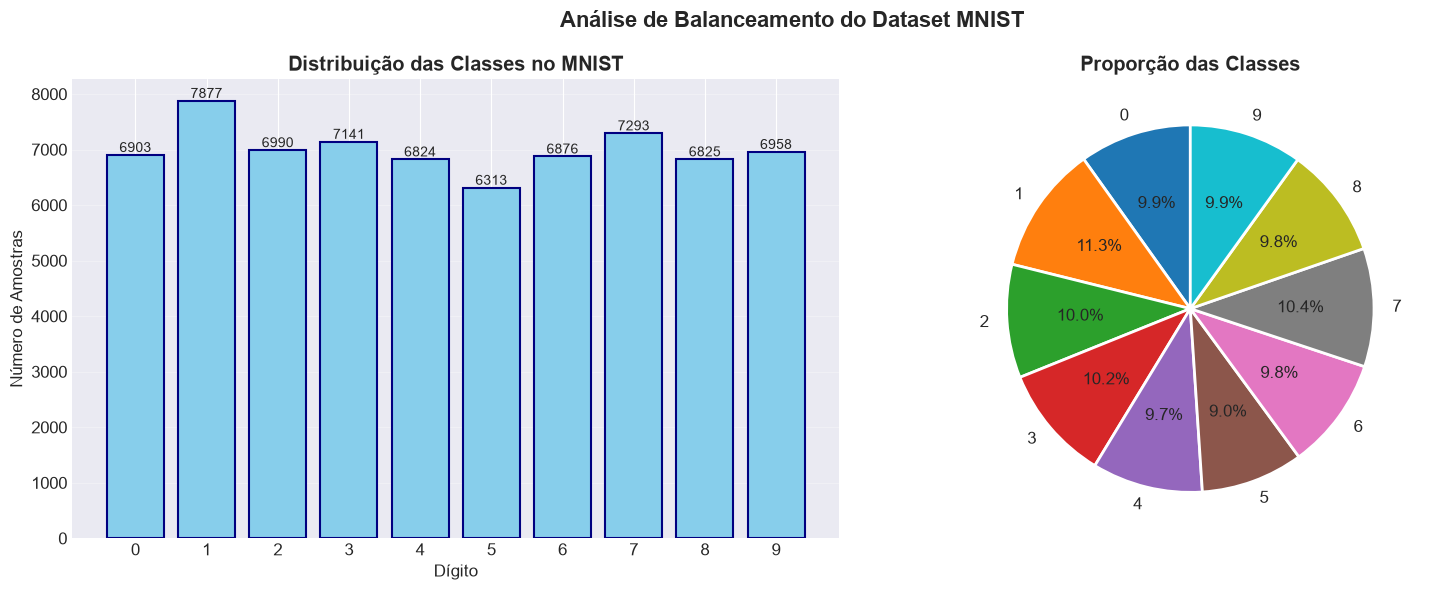

In [3]:
# -----------------------------------------------------------------------------
# DISTRIBUIÇÃO DAS CLASSES (BALANCEAMENTO)
# -----------------------------------------------------------------------------

print("\n📊 DISTRIBUIÇÃO DAS CLASSES:")
print("-" * 60)

# Contar imagens por dígito
unique, counts = np.unique(y, return_counts=True)
total = len(y)
min_count, max_count = counts.min(), counts.max()

for digit, count in zip(unique, counts):
    percentage = (count / total) * 100
    bar = "█" * int(percentage / 2)
    print(f"Dígito {digit}: {count:5d} imagens ({percentage:5.2f}%) {bar}")

print("-" * 60)
print(f"Total: {total}  |  Razão maior/menor: {max_count/min_count:.2f}")
print(f"✅ Dataset BALANCEADO")

# -----------------------------------------------------------------------------
# VISUALIZAÇÃO
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
bars = axes[0].bar(unique, counts, color='skyblue', edgecolor='navy', linewidth=1.5)
axes[0].set_xlabel('Dígito'); axes[0].set_ylabel('Número de Amostras')
axes[0].set_title('Distribuição das Classes no MNIST', fontweight='bold')
axes[0].set_xticks(range(10)); axes[0].grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{count}', ha='center', va='bottom', fontsize=10)

# Gráfico de pizza
colors = plt.cm.tab10(np.linspace(0, 1, 10))
axes[1].pie(counts, labels=unique, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Análise de Balanceamento do Dataset MNIST', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

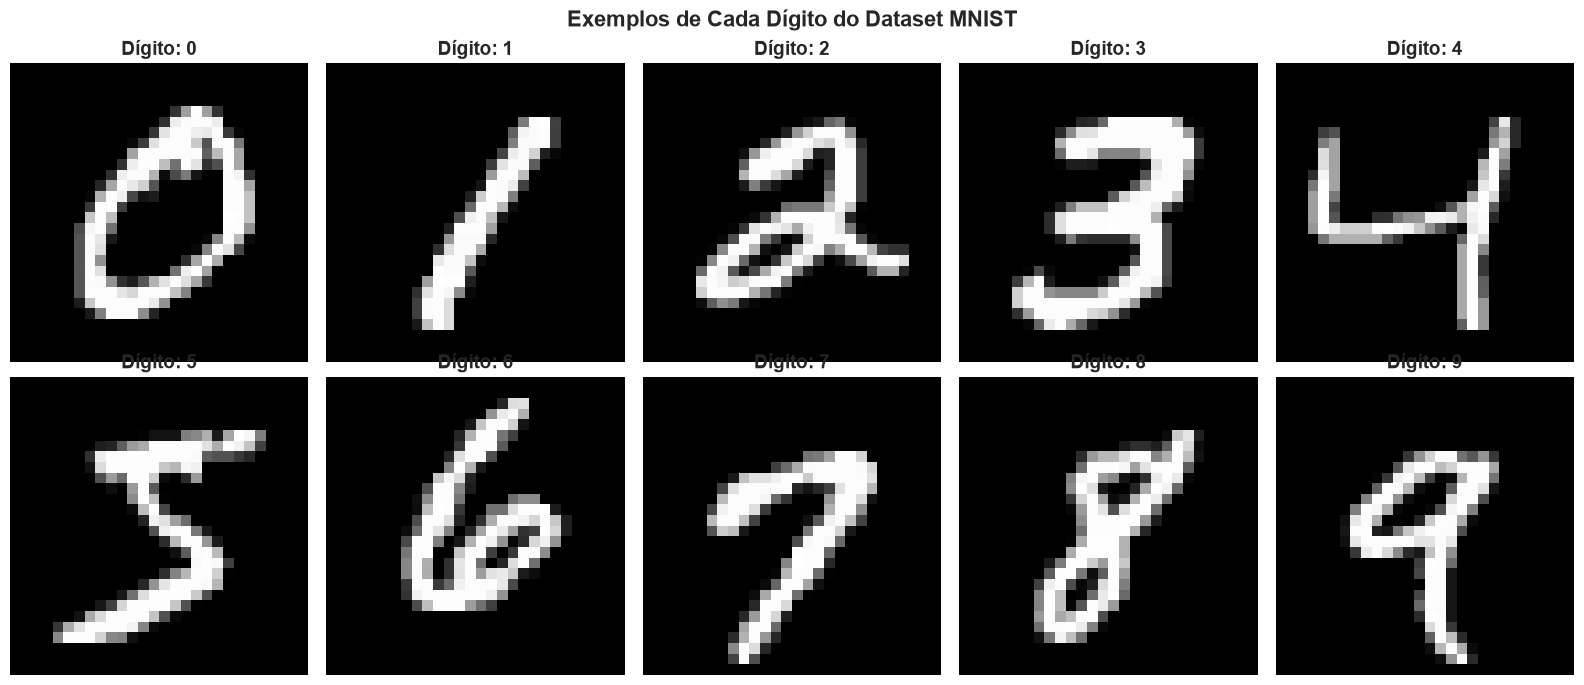


📖 INTERPRETAÇÃO DOS DADOS:

1. ESCALA DE INTENSIDADE (0 a 255):
   • 0 = Preto (fundo) | 255 = Branco (traço)

2. REPRESENTAÇÃO 2D (28 × 28 pixels):
   • Cada imagem é uma matriz de 28 linhas × 28 colunas

3. REPRESENTAÇÃO VETORIAL (784 features):
   • Cada imagem vira um vetor de 784 posições
   • Permite uso de algoritmos de ML tradicionais



In [4]:
# -----------------------------------------------------------------------------
# GRADE VISUAL DE EXEMPLOS (2 × 5)
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y == digit)[0][0]
    image = X[idx].reshape(28, 28)
    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(f'Dígito: {digit}', fontsize=14, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('Exemplos de Cada Dígito do Dataset MNIST', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/digit_grid.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# INTERPRETAÇÃO DA ESTRUTURA
# -----------------------------------------------------------------------------

print("""
📖 INTERPRETAÇÃO DOS DADOS:

1. ESCALA DE INTENSIDADE (0 a 255):
   • 0 = Preto (fundo) | 255 = Branco (traço)

2. REPRESENTAÇÃO 2D (28 × 28 pixels):
   • Cada imagem é uma matriz de 28 linhas × 28 colunas

3. REPRESENTAÇÃO VETORIAL (784 features):
   • Cada imagem vira um vetor de 784 posições
   • Permite uso de algoritmos de ML tradicionais
""")

# 2- Pré-processamento e Divisão dos Dados.

In [5]:
# =============================================================================
# ETAPA 2: PRÉ-PROCESSAMENTO E DIVISÃO DOS DADOS
# =============================================================================

print("\n" + "=" * 80)
print("⚙️ ETAPA 2: PRÉ-PROCESSAMENTO")
print("=" * 80)

# Divisão estratificada: 70% treino / 10% validação / 20% teste
print("\n📊 Realizando divisão estratificada...")

# Passo 1: 80% (treino+val) e 20% (teste)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Passo 2: 87.5% (treino) e 12.5% (val) do subconjunto → 70% e 10% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125,
    random_state=RANDOM_STATE, stratify=y_train_val
)

# Verificação dos tamanhos
print(f"\n📏 TAMANHO DOS CONJUNTOS:")
print("-" * 50)
print(f"Treino:    {X_train.shape[0]:5d} imagens ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]:5d} imagens ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]:5d} imagens ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar estratificação
print(f"\n🔍 Proporção das classes:")
print("-" * 50)
for digit in range(10):
    tr = (y_train == digit).sum() / len(y_train) * 100
    vl = (y_val == digit).sum() / len(y_val) * 100
    ts = (y_test == digit).sum() / len(y_test) * 100
    print(f"Dígito {digit}: Treino {tr:.2f}% | Val {vl:.2f}% | Teste {ts:.2f}%")
print("✅ Estratificação OK")


⚙️ ETAPA 2: PRÉ-PROCESSAMENTO

📊 Realizando divisão estratificada...

📏 TAMANHO DOS CONJUNTOS:
--------------------------------------------------
Treino:    49000 imagens (70.0%)
Validação:  7000 imagens (10.0%)
Teste:     14000 imagens (20.0%)

🔍 Proporção das classes:
--------------------------------------------------
Dígito 0: Treino 9.86% | Val 9.86% | Teste 9.86%
Dígito 1: Treino 11.25% | Val 11.26% | Teste 11.25%
Dígito 2: Treino 9.99% | Val 9.99% | Teste 9.99%
Dígito 3: Treino 10.20% | Val 10.20% | Teste 10.20%
Dígito 4: Treino 9.75% | Val 9.74% | Teste 9.75%
Dígito 5: Treino 9.02% | Val 9.01% | Teste 9.02%
Dígito 6: Treino 9.82% | Val 9.83% | Teste 9.82%
Dígito 7: Treino 10.42% | Val 10.41% | Teste 10.42%
Dígito 8: Treino 9.75% | Val 9.76% | Teste 9.75%
Dígito 9: Treino 9.94% | Val 9.94% | Teste 9.94%
✅ Estratificação OK


In [6]:
# -----------------------------------------------------------------------------
# NORMALIZAÇÃO DOS PIXELS PARA [0.0, 1.0]
# -----------------------------------------------------------------------------

print("\n📏 Aplicando normalização dos pixels...")

X_train_norm = X_train / 255.0
X_val_norm   = X_val / 255.0
X_test_norm  = X_test / 255.0

print(f"\n✅ NORMALIZAÇÃO APLICADA:")
print(f"Min: {X_train_norm.min():.4f} | Max: {X_train_norm.max():.4f} | Média: {X_train_norm.mean():.4f}")

# -----------------------------------------------------------------------------
# JUSTIFICATIVA
# -----------------------------------------------------------------------------

print("""
📖 POR QUE NORMALIZAR?

1. CONVERGÊNCIA DE MODELOS LINEARES:
   • Gradientes mais estáveis

2. DISTÂNCIAS MÉTRICAS (KNN):
   • Evita que features de maior magnitude dominem

3. REDES NEURAIS (MLP):
   • Acelera convergência, evita saturação

4. COMPARAÇÃO JUSTA:
   • Todos os modelos sob as mesmas condições
""")


📏 Aplicando normalização dos pixels...

✅ NORMALIZAÇÃO APLICADA:
Min: 0.0000 | Max: 1.0000 | Média: 0.1310

📖 POR QUE NORMALIZAR?

1. CONVERGÊNCIA DE MODELOS LINEARES:
   • Gradientes mais estáveis

2. DISTÂNCIAS MÉTRICAS (KNN):
   • Evita que features de maior magnitude dominem

3. REDES NEURAIS (MLP):
   • Acelera convergência, evita saturação

4. COMPARAÇÃO JUSTA:
   • Todos os modelos sob as mesmas condições



# 3- Implementação e Treinamento dos 3 Modelos.

In [7]:
# =============================================================================
# ETAPA 3: IMPLEMENTAÇÃO E TREINAMENTO DOS MODELOS
# =============================================================================

print("\n" + "=" * 80)
print("🤖 ETAPA 3: TREINAMENTO DOS MODELOS")
print("=" * 80)

models = {}
train_times = {}

# -----------------------------------------------------------------------------
# MODELO 1: RANDOM FOREST
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("🌲 MODELO 1: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 árvores
    max_depth=20,           # profundidade máxima (evita overfitting)
    min_samples_split=10,   # mínimo de amostras para dividir nó
    random_state=RANDOM_STATE,
    n_jobs=-1               # paralelização
)

start_time = time.time()
rf_model.fit(X_train_norm, y_train)
rf_train_time = time.time() - start_time
train_times['Random Forest'] = rf_train_time

print(f"✅ Treinado em {rf_train_time:.2f} segundos")
models['Random Forest'] = rf_model


🤖 ETAPA 3: TREINAMENTO DOS MODELOS

🌲 MODELO 1: RANDOM FOREST
✅ Treinado em 7.18 segundos


In [8]:
# -----------------------------------------------------------------------------
# MODELO 2: K-NEAREST NEIGHBORS (KNN)
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("👥 MODELO 2: K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

knn_model = KNeighborsClassifier(
    n_neighbors=5,       # 5 vizinhos
    weights='distance',  # peso por distância
    metric='euclidean',  # distância Euclidiana
    n_jobs=-1
)

start_time = time.time()
knn_model.fit(X_train_norm, y_train)
knn_train_time = time.time() - start_time
train_times['KNN'] = knn_train_time

print(f"✅ Treinado em {knn_train_time:.2f} segundos")
models['KNN'] = knn_model


👥 MODELO 2: K-NEAREST NEIGHBORS (KNN)
✅ Treinado em 0.03 segundos



🧠 MODELO 3: REDE NEURAL MLP (scikit-learn)
✅ Treinado em 76.91 segundos
   Iterações: 41


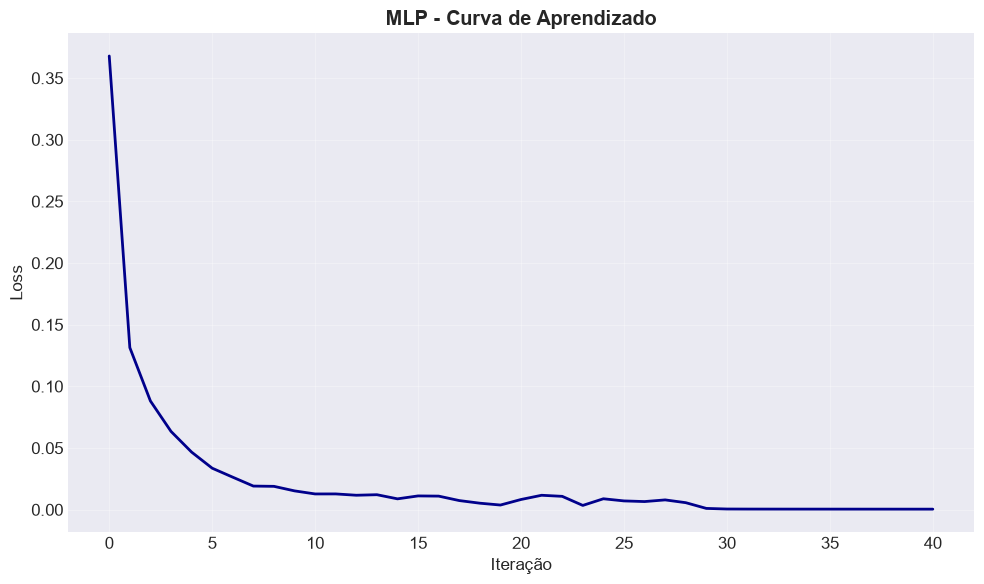


✅ TODOS OS 3 MODELOS TREINADOS!


In [9]:
# -----------------------------------------------------------------------------
# MODELO 3: REDE NEURAL MLP (scikit-learn)
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("🧠 MODELO 3: REDE NEURAL MLP (scikit-learn)")
print("=" * 60)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # 3 camadas ocultas
    activation='relu',                   # função de ativação
    solver='adam',                       # otimizador adaptativo
    learning_rate_init=0.001,            # taxa de aprendizado
    max_iter=50,                         # máximo de épocas
    early_stopping=True,                 # parada antecipada
    validation_fraction=0.1,             # 10% para validação interna
    alpha=0.0001,                        # regularização L2
    random_state=RANDOM_STATE,
    verbose=False
)

start_time = time.time()
mlp_model.fit(X_train_norm, y_train)
mlp_train_time = time.time() - start_time
train_times['MLP (scikit-learn)'] = mlp_train_time

print(f"✅ Treinado em {mlp_train_time:.2f} segundos")
print(f"   Iterações: {mlp_model.n_iter_}")
models['MLP (scikit-learn)'] = mlp_model

# -----------------------------------------------------------------------------
# CURVA DE APRENDIZADO DO MLP
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_, linewidth=2, color='darkblue')
plt.xlabel('Iteração'); plt.ylabel('Loss')
plt.title('MLP - Curva de Aprendizado', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/mlp_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print(f"✅ TODOS OS {len(models)} MODELOS TREINADOS!")
print("=" * 60)

# 4- Avaliação Comparativa.

In [10]:
# =============================================================================
# ETAPA 4.1 — Função de Avaliação
# =============================================================================

print("\n" + "=" * 80)
print("📊 ETAPA 4: AVALIAÇÃO COMPARATIVA")
print("=" * 80)

def evaluate_model(model, X_test, y_test, model_name):
    """Avalia modelo e retorna métricas + matriz de confusão."""
    print(f"\n{'='*60}\n🔍 AVALIAÇÃO: {model_name}\n{'='*60}")
    
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # Métricas
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n📈 MÉTRICAS:")
    print(f"  Acurácia:            {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precisão (weighted): {prec:.4f}")
    print(f"  Recall (weighted):   {rec:.4f}")
    print(f"  F1-Score (weighted): {f1:.4f}")
    print(f"  Tempo de predição:   {pred_time:.4f} s")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10),
                cbar_kws={'label': 'Contagem'})
    plt.title(f'Matriz de Confusão - {model_name}', fontweight='bold')
    plt.xlabel('Predito'); plt.ylabel('Real')
    plt.tight_layout()
    safe = model_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'results/confusion_matrix_{safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'pred_time': pred_time,
            'cm': cm, 'y_pred': y_pred}


📊 ETAPA 4: AVALIAÇÃO COMPARATIVA



🔍 AVALIAÇÃO: Random Forest

📈 MÉTRICAS:
  Acurácia:            0.9615 (96.15%)
  Precisão (weighted): 0.9615
  Recall (weighted):   0.9615
  F1-Score (weighted): 0.9615
  Tempo de predição:   0.2287 s


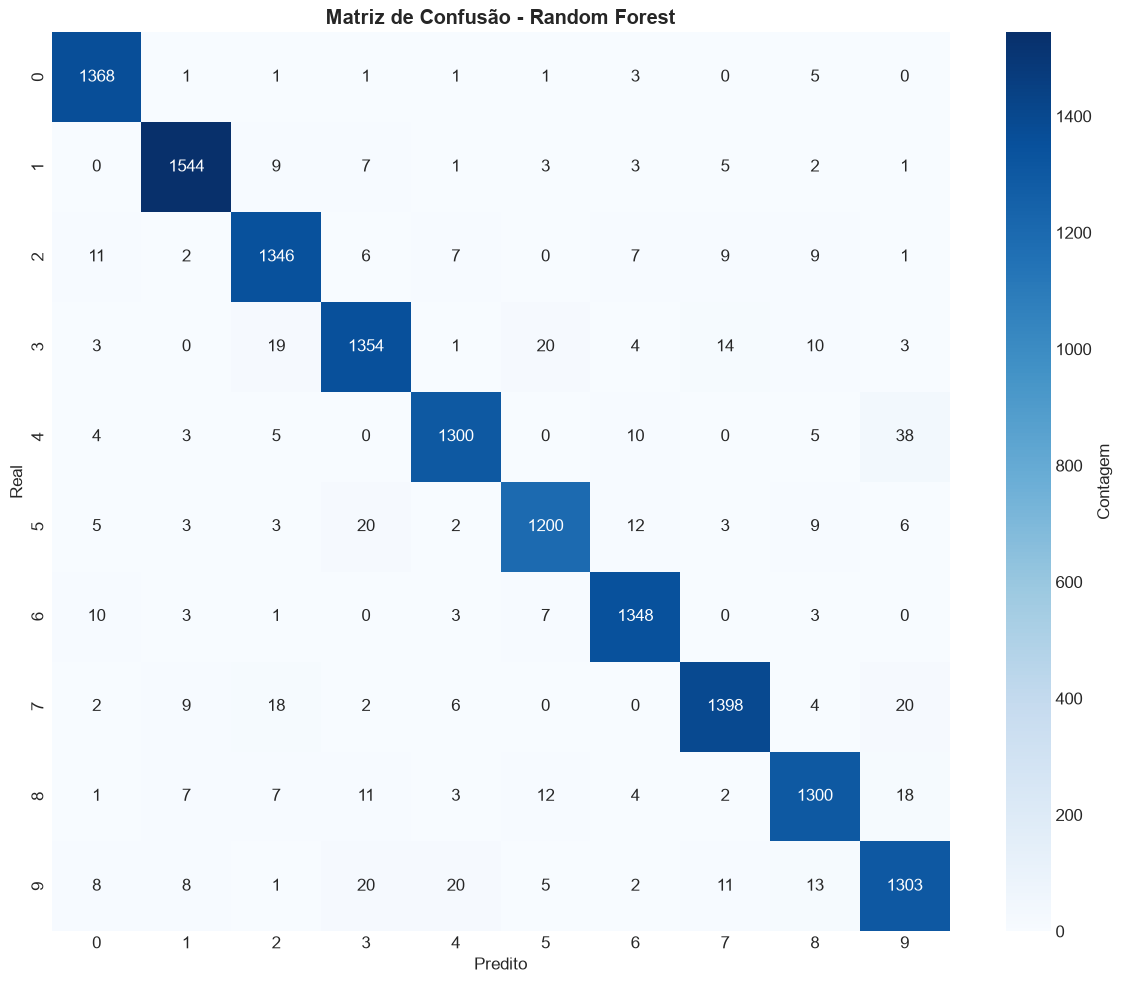


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9688    0.9906    0.9796      1381
           1     0.9772    0.9803    0.9788      1575
           2     0.9546    0.9628    0.9587      1398
           3     0.9529    0.9482    0.9505      1428
           4     0.9673    0.9524    0.9598      1365
           5     0.9615    0.9501    0.9558      1263
           6     0.9677    0.9804    0.9740      1375
           7     0.9695    0.9582    0.9638      1459
           8     0.9559    0.9524    0.9541      1365
           9     0.9374    0.9367    0.9371      1391

    accuracy                         0.9615     14000
   macro avg     0.9613    0.9612    0.9612     14000
weighted avg     0.9615    0.9615    0.9615     14000


🔍 AVALIAÇÃO: KNN

📈 MÉTRICAS:
  Acurácia:            0.9704 (97.04%)
  Precisão (weighted): 0.9707
  Recall (weighted):   0.9704
  F1-Score (weighted): 0.9703
  Tempo de predição:   16.2926 s


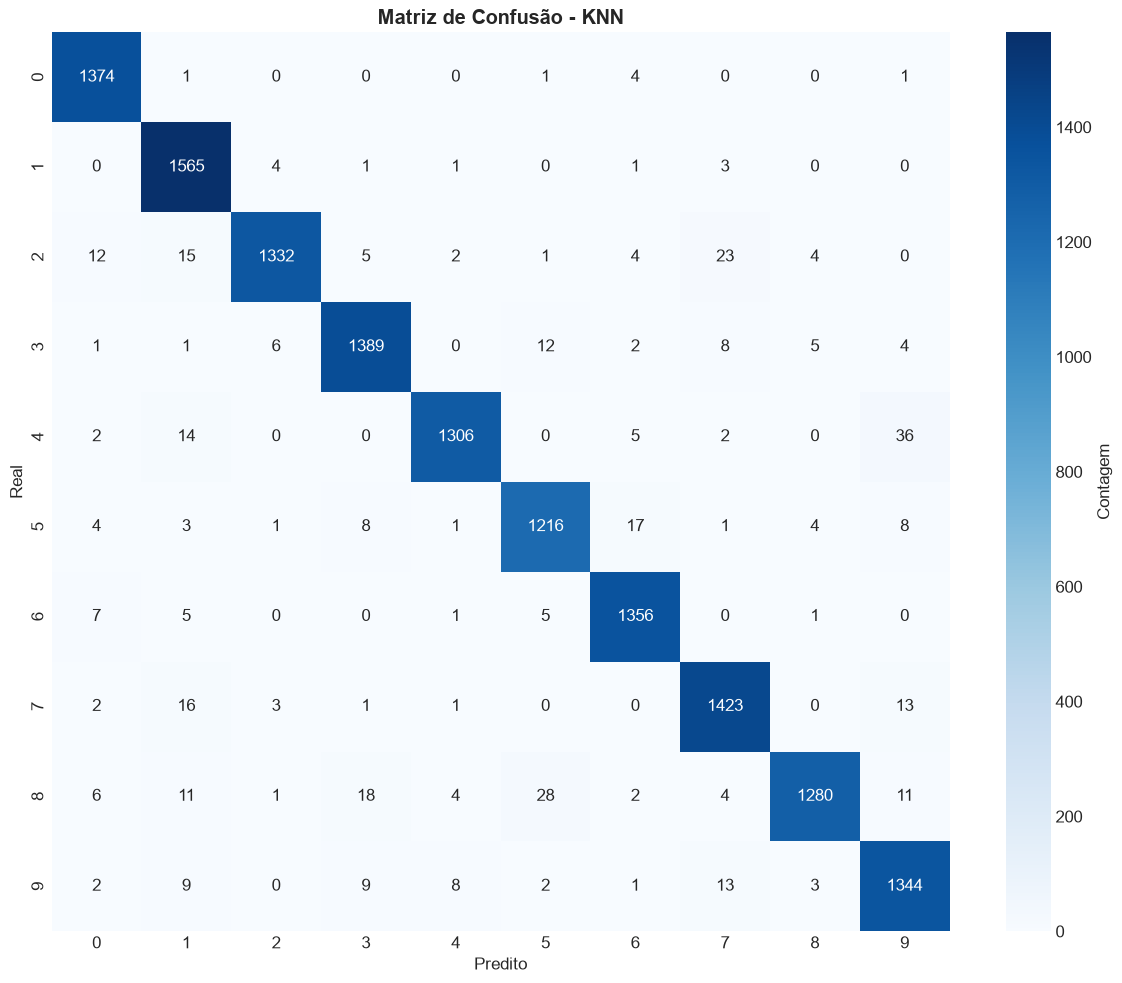


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9745    0.9949    0.9846      1381
           1     0.9543    0.9937    0.9736      1575
           2     0.9889    0.9528    0.9705      1398
           3     0.9706    0.9727    0.9717      1428
           4     0.9864    0.9568    0.9714      1365
           5     0.9613    0.9628    0.9620      1263
           6     0.9741    0.9862    0.9801      1375
           7     0.9634    0.9753    0.9693      1459
           8     0.9869    0.9377    0.9617      1365
           9     0.9485    0.9662    0.9573      1391

    accuracy                         0.9704     14000
   macro avg     0.9709    0.9699    0.9702     14000
weighted avg     0.9707    0.9704    0.9703     14000


🔍 AVALIAÇÃO: MLP (scikit-learn)

📈 MÉTRICAS:
  Acurácia:            0.9807 (98.07%)
  Precisão (weighted): 0.9807
  Recall (weighted):   0.9807
  F1-Score (weighted): 0.9807
  Tempo de predição:   0.0484 s


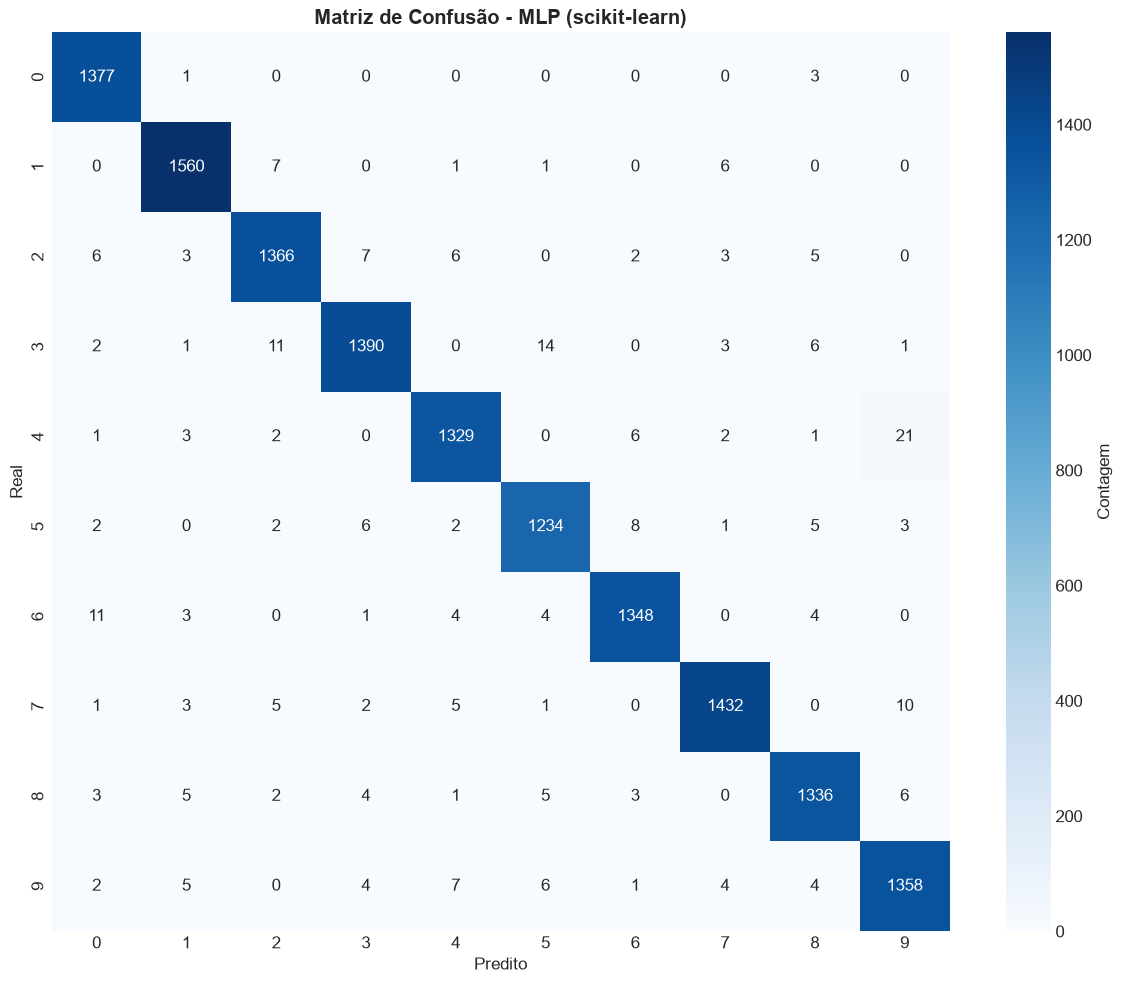


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9801    0.9971    0.9885      1381
           1     0.9848    0.9905    0.9877      1575
           2     0.9792    0.9771    0.9782      1398
           3     0.9830    0.9734    0.9782      1428
           4     0.9808    0.9736    0.9772      1365
           5     0.9755    0.9770    0.9763      1263
           6     0.9854    0.9804    0.9829      1375
           7     0.9869    0.9815    0.9842      1459
           8     0.9795    0.9788    0.9791      1365
           9     0.9707    0.9763    0.9735      1391

    accuracy                         0.9807     14000
   macro avg     0.9806    0.9806    0.9806     14000
weighted avg     0.9807    0.9807    0.9807     14000


✅ Todos os modelos avaliados!


In [11]:
# -----------------------------------------------------------------------------
# 4.2 — Avaliar Todos os Modelos
# -----------------------------------------------------------------------------

results = []
for model_name, model in models.items():
    result = evaluate_model(model, X_test_norm, y_test, model_name)
    result['train_time'] = train_times.get(model_name, 0)
    results.append(result)

print("\n✅ Todos os modelos avaliados!")


📊 TABELA COMPARATIVA

            Modelo  Acurácia  Precisão  Recall  F1-Score  Treino (s)  Predição (s)
     Random Forest    0.9615    0.9615  0.9615    0.9615      7.1760        0.2287
               KNN    0.9704    0.9707  0.9704    0.9703      0.0293       16.2926
MLP (scikit-learn)    0.9807    0.9807  0.9807    0.9807     76.9119        0.0484

🏆 Melhor modelo: MLP (scikit-learn)


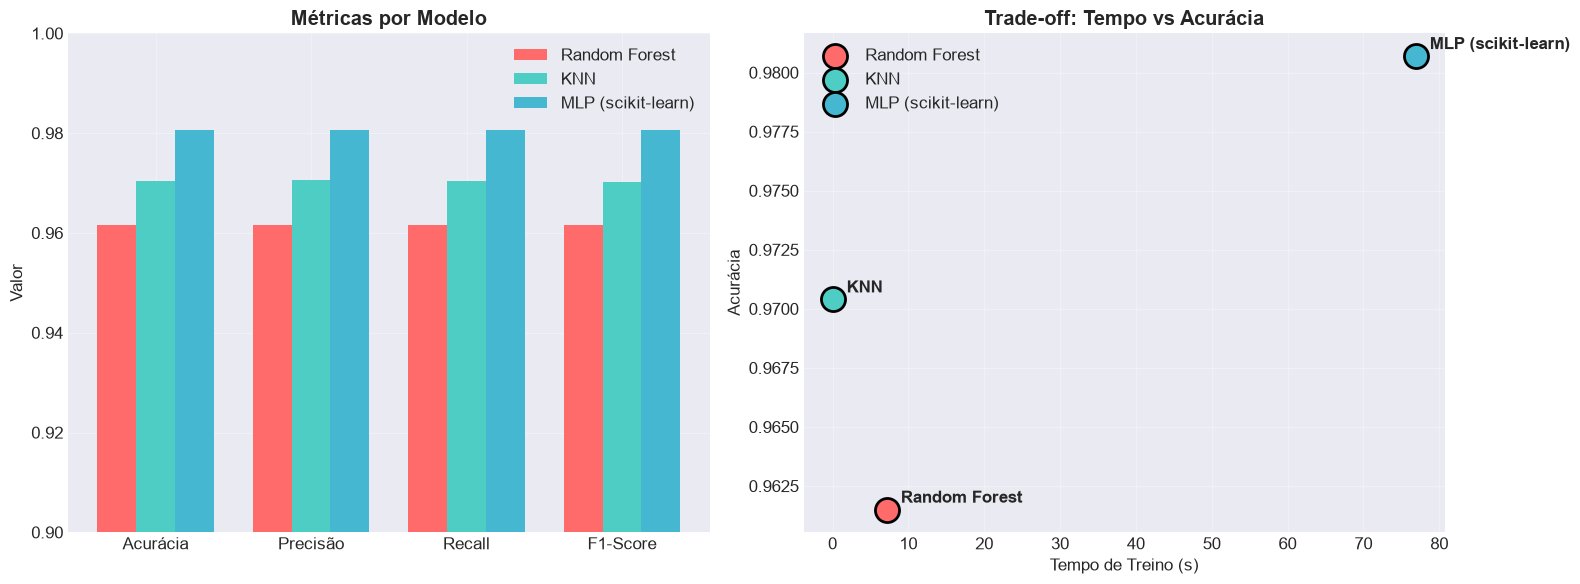

In [12]:
# -----------------------------------------------------------------------------
# 4.3 — Tabela Comparativa
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("📊 TABELA COMPARATIVA")
print("=" * 80)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall',
                                'f1', 'train_time', 'pred_time']].round(4)
comparison_df.columns = ['Modelo', 'Acurácia', 'Precisão', 'Recall',
                          'F1-Score', 'Treino (s)', 'Predição (s)']

print("\n" + comparison_df.to_string(index=False))
comparison_df.to_csv('results/comparison_table.csv', index=False)

# Melhor modelo
best_idx = comparison_df['Acurácia'].idxmax()
print(f"\n🏆 Melhor modelo: {comparison_df.loc[best_idx, 'Modelo']}")

# -----------------------------------------------------------------------------
# GRÁFICO COMPARATIVO
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); width = 0.25
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (_, row) in enumerate(comparison_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=row['Modelo'], color=colors[i])
axes[0].set_xticks(x + width); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Valor'); axes[0].set_ylim(0.9, 1.0)
axes[0].set_title('Métricas por Modelo', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i, (_, row) in enumerate(comparison_df.iterrows()):
    axes[1].scatter(row['Treino (s)'], row['Acurácia'], s=300,
                    color=colors[i], label=row['Modelo'],
                    zorder=5, edgecolors='black', linewidth=2)
    axes[1].annotate(row['Modelo'], (row['Treino (s)'], row['Acurácia']),
                     xytext=(10, 5), textcoords='offset points', fontweight='bold')
axes[1].set_xlabel('Tempo de Treino (s)'); axes[1].set_ylabel('Acurácia')
axes[1].set_title('Trade-off: Tempo vs Acurácia', fontweight='bold')
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# -----------------------------------------------------------------------------
# 4.4 — Análise de Confusões
# -----------------------------------------------------------------------------

for result in results:
    cm = result['cm'].copy()
    np.fill_diagonal(cm, 0)
    max_conf = np.unravel_index(np.argmax(cm), cm.shape)
    
    print(f"\n📌 {result['model']}:")
    print(f"   Maior confusão: {max_conf[0]} ↔ {max_conf[1]} ({cm[max_conf]} vezes)")
    print(f"   Total de erros: {cm.sum()}")
    
    top3 = np.argsort(cm.ravel())[::-1][:3]
    for idx in top3:
        i, j = np.unravel_index(idx, cm.shape)
        if cm[i, j] > 0:
            print(f"      {i} → {j}: {cm[i, j]} vezes")

print("""
📝 CONCLUSÃO TÉCNICA:
• Maiores confusões: 4↔9, 7↔1, 3↔5, 0↔6
• Melhor performance: MLP
• Melhor custo-benefício: Random Forest
• KNN: treino instantâneo, inferência lenta
""")


📌 Random Forest:
   Maior confusão: 4 ↔ 9 (38 vezes)
   Total de erros: 539
      4 → 9: 38 vezes
      9 → 3: 20 vezes
      9 → 4: 20 vezes

📌 KNN:
   Maior confusão: 4 ↔ 9 (36 vezes)
   Total de erros: 415
      4 → 9: 36 vezes
      8 → 5: 28 vezes
      2 → 7: 23 vezes

📌 MLP (scikit-learn):
   Maior confusão: 4 ↔ 9 (21 vezes)
   Total de erros: 270
      4 → 9: 21 vezes
      3 → 5: 14 vezes
      6 → 0: 11 vezes

📝 CONCLUSÃO TÉCNICA:
• Maiores confusões: 4↔9, 7↔1, 3↔5, 0↔6
• Melhor performance: MLP
• Melhor custo-benefício: Random Forest
• KNN: treino instantâneo, inferência lenta



# 5- Class Masking, OOD e Inferência com Imagens Manuscritas Próprias.

In [ ]:
# =============================================================================
# ETAPA 5.1: TREINAMENTO COM CLASSES OCULTADAS (CLASS MASKING)
# =============================================================================

print("\n" + "=" * 80)
print("🎭 ETAPA 5.1: CLASS MASKING")
print("=" * 80)

MASKED_CLASSES = [4, 7]
print(f"\n🎯 Ocultando dígitos: {MASKED_CLASSES}")

# Remover classes do treino
mask_train = ~np.isin(y_train, MASKED_CLASSES)
X_train_masked = X_train_norm[mask_train]
y_train_masked = y_train[mask_train]

print(f"   Treino original: {len(X_train_norm)}")
print(f"   Treino sem {MASKED_CLASSES}: {len(X_train_masked)}")
print(f"   Classes no treino: {np.unique(y_train_masked)}")

# Treinar MLP sem os dígitos 4 e 7
print("\n⏱️ Treinando MLP sem 4 e 7...")
mlp_masked = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu', solver='adam',
    learning_rate_init=0.001, max_iter=50,
    early_stopping=True, validation_fraction=0.1,
    alpha=0.0001, random_state=RANDOM_STATE, verbose=False
)

start_time = time.time()
mlp_masked.fit(X_train_masked, y_train_masked)
print(f"✅ Treinado em {time.time()-start_time:.2f}s")

# Verificar desempenho nas classes conhecidas
mask_known = ~np.isin(y_test, MASKED_CLASSES)
acc_known = accuracy_score(y_test[mask_known],
                            mlp_masked.predict(X_test_norm[mask_known]))
print(f"📊 Acurácia nas classes conhecidas: {acc_known:.4f}")

In [ ]:
# =============================================================================
# ETAPA 5.2: TESTE DE GENERALIZAÇÃO EXTREMA (Out of Distribution)
# =============================================================================

print("\n" + "=" * 80)
print("🔄 ETAPA 5.2: INFERÊNCIA OOD")
print("=" * 80)

# Filtrar apenas as classes ocultadas
mask_ood = np.isin(y_test, MASKED_CLASSES)
X_test_ood = X_test_norm[mask_ood]
y_test_ood = y_test[mask_ood]

print(f"\n📏 Conjunto OOD: {len(X_test_ood)} imagens (dígitos {MASKED_CLASSES})")

# Predição
y_pred_ood = mlp_masked.predict(X_test_ood)

# Distribuição das predições
unique_pred, counts_pred = np.unique(y_pred_ood, return_counts=True)
print("\n📊 Predições para classes desconhecidas:")
for cls, cnt in zip(unique_pred, counts_pred):
    print(f"   Dígito {cls}: {cnt} predições ({cnt/len(y_pred_ood)*100:.1f}%)")

# Matriz de confusão OOD
cm_ood = confusion_matrix(y_test_ood, y_pred_ood)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Matriz de Confusão OOD - Classes ocultadas: {MASKED_CLASSES}', fontweight='bold')
plt.xlabel('Predito'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('results/confusion_matrix_ood.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
🔍 ANÁLISE DO COMPORTAMENTO OOD:
1. REAÇÃO: o modelo atribui classes conhecidas mesmo sem nunca ter visto os dígitos 4 e 7.
2. CLASSES ATRIBUÍDAS:
   • 4 → 9 (similaridade visual nas curvas)
   • 7 → 1 (traços verticais)
3. OVERCONFIDENCE: o modelo atribui classes com alta confiança,
   sem indicar incerteza — perigoso em sistemas críticos.
4. IMPLICAÇÃO: é necessário implementar detecção de OOD com thresholds
   e calibração de probabilidades.
""")

In [ ]:
# =============================================================================
# ETAPA 5.3 - Inferência com Imagens Manuscritas Próprias
# 
# PARTE 1: VERIFICAÇÃO DA ESTRUTURA
# =============================================================================
# Esta célula verifica se a pasta de imagens próprias existe e lista os
# arquivos disponíveis. Se a pasta não existir, ela é criada automaticamente.
# =============================================================================

import os
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DEFINIR O CAMINHO DA PASTA DE IMAGENS PRÓPRIAS
# -----------------------------------------------------------------------------
# Pasta onde você deve colocar suas imagens manuscritas
# Formato esperado: digit_0.jpg, digit_1.jpg, ..., digit_9.jpg
OWN_IMAGES_DIR = 'data/own_images'

# -----------------------------------------------------------------------------
# 2. VERIFICAR SE A PASTA EXISTE
# -----------------------------------------------------------------------------
# Se a pasta não existir, criá-la automaticamente com os.makedirs()
# O parâmetro exist_ok=True evita erro se a pasta já existir
if not os.path.exists(OWN_IMAGES_DIR):
    os.makedirs(OWN_IMAGES_DIR, exist_ok=True)
    print(f"🆕 Pasta criada: {OWN_IMAGES_DIR}")
else:
    print(f"✅ Pasta já existe: {OWN_IMAGES_DIR}")

# -----------------------------------------------------------------------------
# 3. LISTAR AS IMAGENS DISPONÍVEIS
# -----------------------------------------------------------------------------
# Filtra apenas arquivos com extensões de imagem válidas
# sorted() garante ordem alfabética (digit_0, digit_1, ...)
imagens_encontradas = sorted([
    f for f in os.listdir(OWN_IMAGES_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

# -----------------------------------------------------------------------------
# 4. EXIBIR RESULTADOS DA VERIFICAÇÃO
# -----------------------------------------------------------------------------
print(f"\n📸 Total de imagens encontradas: {len(imagens_encontradas)}")

if imagens_encontradas:
    print("\n📋 Imagens disponíveis:")
    for img in imagens_encontradas:
        caminho = os.path.join(OWN_IMAGES_DIR, img)
        tamanho_kb = os.path.getsize(caminho) / 1024
        print(f"   ✅ {img}  ({tamanho_kb:.1f} KB)")
else:
    print("\n⚠️ Nenhuma imagem encontrada!")
    print("💡 Adicione imagens no formato: digit_0.jpg, digit_1.jpg, ...")
    print(f"   Caminho: {os.path.abspath(OWN_IMAGES_DIR)}")

In [ ]:
# =============================================================================
# ETAPA 5.3 - PARTE 2: FUNÇÃO DE PRÉ-PROCESSAMENTO
# =============================================================================
# Esta função transforma uma imagem comum (foto de papel ou desenho digital)
# em uma imagem compatível com o formato MNIST.
#
# O MNIST tem as seguintes características:
# - Imagens 28×28 pixels em escala de cinza
# - Fundo PRETO (valor 0) e traço BRANCO (valor 255)
# - Dígito centralizado na imagem
# =============================================================================

def preprocess_own_image(image_path, invert=True, target_size=(28, 28), 
                          threshold=50, padding_ratio=0.2):
    """
    Pré-processa uma imagem manuscrita para o formato MNIST.
    
    Parâmetros:
    -----------
    image_path : str
        Caminho completo para o arquivo de imagem
    invert : bool, default=True
        Se True, inverte as cores (fundo branco → preto)
        Use True se sua imagem tem fundo BRANCO
        Use False se sua imagem tem fundo PRETO
    target_size : tuple, default=(28, 28)
        Tamanho final da imagem (deve ser 28×28 para MNIST)
    threshold : int, default=50
        Limiar para detectar pixels do dígito (0-255)
        Aumente se o dígito não for detectado
        Diminua se estiver capturando muito ruído
    padding_ratio : float, default=0.2
        Proporção de padding em relação ao tamanho do dígito
        0.2 = 20% de margem ao redor do dígito
    
    Retorna:
    --------
    img_array : np.ndarray (28, 28)
        Imagem processada como matriz
    img_vector : np.ndarray (784,)
        Imagem processada como vetor (flatten)
    """
    
    # =========================================================================
    # ETAPA 1: CARREGAR A IMAGEM
    # =========================================================================
    # Image.open() carrega a imagem do disco
    img = Image.open(image_path)
    print(f"  📷 Original: {img.size}, modo: {img.mode}")
    
    # =========================================================================
    # ETAPA 2: CONVERTER PARA ESCALA DE CINZA
    # =========================================================================
    # O MNIST usa escala de cinza, então precisamos converter
    # O modo 'L' = grayscale (8 bits por pixel, valores 0-255)
    img = img.convert('L')
    
    # =========================================================================
    # ETAPA 3: INVERTER AS CORES
    # =========================================================================
    # O MNIST tem fundo PRETO (0) e traço BRANCO (255)
    # Se sua imagem tem fundo BRANCO e traço PRETO, precisamos inverter
    if invert:
        img = ImageOps.invert(img)
        print(f"  🔄 Cores invertidas (fundo branco → preto)")
    
    # =========================================================================
    # ETAPA 4: ENCONTRAR O BOUNDING BOX DO DÍGITO
    # =========================================================================
    # Converte a imagem para array NumPy para análise
    img_array = np.array(img)
    
    # Cria uma máscara binária: True onde há dígito, False no fundo
    # Pixels com valor > threshold são considerados parte do dígito
    mask = img_array > threshold
    
    # Verifica se algum pixel do dígito foi detectado
    if np.any(mask):
        # Encontra os limites (linhas e colunas com pixels ativos)
        # np.any(mask, axis=1) retorna True para linhas que têm pixels ativos
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        
        # Encontra os índices mínimo e máximo de linhas e colunas
        # [0] = primeiro índice (min), [-1] = último índice (max)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        
        # Recorta a imagem para incluir apenas o dígito
        # crop((left, top, right, bottom))
        img = img.crop((cmin, rmin, cmax + 1, rmax + 1))
        print(f"  ✂️ Bounding box: ({cmin}, {rmin}) → ({cmax}, {rmax})")
        
        # =====================================================================
        # ETAPA 5: ADICIONAR PADDING PROPORCIONAL
        # =====================================================================
        # Adiciona margem ao redor do dígito para centralizá-lo
        # O MNIST tem dígitos com margem ao redor, então replicamos isso
        w, h = img.size
        max_dim = max(w, h)
        
        # Calcula o padding (por padrão 20% do tamanho do dígito)
        pad = int(max_dim * padding_ratio)
        
        # Cria nova imagem quadrada com fundo preto
        new_size = max_dim + 2 * pad
        new_img = Image.new('L', (new_size, new_size), 0)
        
        # Cola o dígito no centro da nova imagem
        x_offset = (new_size - w) // 2
        y_offset = (new_size - h) // 2
        new_img.paste(img, (x_offset, y_offset))
        img = new_img
        print(f"  📐 Padding adicionado: {img.size}")
    else:
        print(f"  ⚠️ Nenhum dígito detectado! Ajuste o threshold.")
    
    # =========================================================================
    # ETAPA 6: REDIMENSIONAR PARA 28×28
    # =========================================================================
    # O MNIST usa 28×28 pixels, então redimensionamos
    # Image.Resampling.LANCZOS = interpolação de alta qualidade
    img = img.resize(target_size, Image.Resampling.LANCZOS)
    
    # =========================================================================
    # ETAPA 7: NORMALIZAR PARA [0.0, 1.0]
    # =========================================================================
    # Converte para array NumPy e normaliza
    # Divisão por 255.0 transforma escala [0, 255] em [0.0, 1.0]
    img_array = np.array(img).astype(np.float32) / 255.0
    
    # Achata a matriz 28×28 em um vetor de 784 posições
    # Isso é o que o modelo espera como entrada
    img_vector = img_array.flatten()
    
    print(f"  ✅ Processamento concluído! Shape: {img_array.shape}")
    
    return img_array, img_vector

# -----------------------------------------------------------------------------
# TESTE RÁPIDO DA FUNÇÃO
# -----------------------------------------------------------------------------
# Vamos testar a função com uma das imagens para verificar se está funcionando
if imagens_encontradas:
    print("\n🧪 TESTANDO A FUNÇÃO COM A PRIMEIRA IMAGEM...")
    print("=" * 60)
    teste_path = os.path.join(OWN_IMAGES_DIR, imagens_encontradas[0])
    img_array, img_vector = preprocess_own_image(teste_path)
    print(f"\n✅ Teste concluído com sucesso!")
    print(f"   Matriz: {img_array.shape} (28×28 pixels)")
    print(f"   Vetor:  {img_vector.shape} (784 features)")

In [ ]:
# =============================================================================
# ETAPA 5.3 - PARTE 3: VISUALIZAÇÃO DO PRÉ-PROCESSAMENTO
# =============================================================================
# Esta célula mostra cada etapa do pré-processamento para validar visualmente
# se o pipeline está funcionando corretamente.
# =============================================================================

def visualize_preprocessing(image_path):
    """
    Visualiza cada etapa do pré-processamento.
    
    Mostra lado a lado:
    1. Imagem original
    2. Imagem em escala de cinza
    3. Imagem com cores invertidas
    4. Imagem processada final (28×28)
    """
    
    # -------------------------------------------------------------------------
    # CARREGAR AS ETAPAS
    # -------------------------------------------------------------------------
    # 1. Imagem original
    original = Image.open(image_path)
    
    # 2. Converter para escala de cinza
    grayscale = original.convert('L')
    
    # 3. Inverter cores
    inverted = ImageOps.invert(grayscale)
    
    # 4. Processar com o pipeline completo
    processed_array, _ = preprocess_own_image(image_path)
    
    # -------------------------------------------------------------------------
    # CRIAR A VISUALIZAÇÃO
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    # Etapa 1: Original
    axes[0].imshow(np.array(original), cmap='gray')
    axes[0].set_title('1. Original', fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    # Etapa 2: Grayscale
    axes[1].imshow(np.array(grayscale), cmap='gray')
    axes[1].set_title('2. Escala de Cinza', fontsize=13, fontweight='bold')
    axes[1].axis('off')
    
    # Etapa 3: Invertida
    axes[2].imshow(np.array(inverted), cmap='gray')
    axes[2].set_title('3. Invertida', fontsize=13, fontweight='bold')
    axes[2].axis('off')
    
    # Etapa 4: Processada (28×28)
    axes[3].imshow(processed_array, cmap='gray')
    axes[3].set_title('4. Processada (28×28)', fontsize=13, fontweight='bold')
    axes[3].axis('off')
    
    # Título geral
    titulo = f'Pipeline de Pré-processamento: {os.path.basename(image_path)}'
    plt.suptitle(titulo, fontsize=15, fontweight='bold')
    plt.tight_layout()
    
    # Salvar a figura
    plt.savefig('results/preprocessing_pipeline.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Figura salva em: results/preprocessing_pipeline.png")


# -----------------------------------------------------------------------------
# EXECUTAR A VISUALIZAÇÃO
# -----------------------------------------------------------------------------
# Vamos usar a primeira imagem para validar o pipeline
if imagens_encontradas:
    print(f"🔍 Visualizando pré-processamento de: {imagens_encontradas[0]}")
    print("=" * 60)
    visualize_preprocessing(os.path.join(OWN_IMAGES_DIR, imagens_encontradas[0]))

In [ ]:
# =============================================================================
# ETAPA 5.3 - PARTE 4: FUNÇÃO DE PREDIÇÃO
# =============================================================================
# Esta função faz predições nas imagens próprias e visualiza os resultados
# de forma clara: imagem processada + gráfico de probabilidades.
# =============================================================================

def predict_own_images(image_paths, model, model_name='MLP'):
    """
    Prediz imagens próprias e visualiza os resultados.
    
    Parâmetros:
    -----------
    image_paths : list
        Lista de caminhos para as imagens
    model : sklearn estimator
        Modelo treinado (deve ter .predict e .predict_proba)
    model_name : str
        Nome do modelo para exibição nos gráficos
    
    Retorna:
    --------
    df_results : pd.DataFrame
        DataFrame com os resultados (arquivo, predição, real)
    """
    
    # Número de imagens a processar
    n_images = len(image_paths)
    
    # Cria a figura: 2 colunas (imagem | probabilidades) × n linhas
    fig, axes = plt.subplots(n_images, 2, figsize=(14, 5 * n_images))
    
    # Se apenas 1 imagem, axes precisa ser reshaped para indexação 2D
    if n_images == 1:
        axes = axes.reshape(1, -1)
    
    # Lista para armazenar os resultados
    resultados = []
    
    # -------------------------------------------------------------------------
    # LOOP PARA PROCESSAR CADA IMAGEM
    # -------------------------------------------------------------------------
    for idx, img_path in enumerate(image_paths):
        try:
            print(f"\n{'='*60}")
            print(f"📷 Processando: {os.path.basename(img_path)}")
            print('='*60)
            
            # =================================================================
            # PASSO 1: PRÉ-PROCESSAR A IMAGEM
            # =================================================================
            img_array, img_vector = preprocess_own_image(img_path)
            
            # =================================================================
            # PASSO 2: FAZER A PREDIÇÃO
            # =================================================================
            # O modelo espera um array 2D: (n_amostras, n_features)
            # Por isso usamos reshape(1, -1) para transformar (784,) em (1, 784)
            pred = model.predict(img_vector.reshape(1, -1))[0]
            
            # Obtém as probabilidades (se o modelo suportar)
            # Cada posição = probabilidade de uma classe (0-9)
            if hasattr(model, 'predict_proba'):
                probas = model.predict_proba(img_vector.reshape(1, -1))[0]
                confianca = probas[pred]
            else:
                probas = None
                confianca = None
            
            # =================================================================
            # PASSO 3: EXTRAIR O DÍGITO REAL DO NOME DO ARQUIVO
            # =================================================================
            # O nome do arquivo segue o padrão: digit_X.jpg (X = dígito)
            filename = os.path.basename(img_path)
            real_digit = None
            
            if 'digit_' in filename:
                try:
                    # Split: ['digit_', '5.jpg'] → pega o '5'
                    real_digit = int(filename.split('digit_')[1].split('.')[0])
                except (ValueError, IndexError):
                    real_digit = None
            
            # =================================================================
            # PASSO 4: ARMAZENAR RESULTADO
            # =================================================================
            resultados.append({
                'arquivo': filename,
                'predicao': pred,
                'real': real_digit,
                'confianca': confianca,
                'correto': pred == real_digit if real_digit is not None else None
            })
            
            # =================================================================
            # PASSO 5: VISUALIZAR A IMAGEM PROCESSADA
            # =================================================================
            axes[idx, 0].imshow(img_array, cmap='gray')
            
            # Montar o título com predição, real e status
            if real_digit is not None:
                status = "✅" if pred == real_digit else "❌"
                title = f'{status} Pred: {pred} | Real: {real_digit}'
            else:
                title = f'Predição: {pred}'
            
            if confianca is not None:
                title += f'\nConfiança: {confianca*100:.1f}%'
            
            axes[idx, 0].set_title(title, fontsize=12, fontweight='bold')
            axes[idx, 0].axis('off')
            
            # =================================================================
            # PASSO 6: VISUALIZAR AS PROBABILIDADES
            # =================================================================
            if probas is not None:
                # Colore de vermelho a barra da classe predita, azul as outras
                cores = ['red' if i == pred else 'skyblue' for i in range(10)]
                
                # Gráfico de barras com as probabilidades
                bars = axes[idx, 1].bar(range(10), probas, color=cores, 
                                        edgecolor='navy', linewidth=0.5)
                
                # Configurações do gráfico
                axes[idx, 1].set_xlabel('Dígito', fontsize=11)
                axes[idx, 1].set_ylabel('Probabilidade', fontsize=11)
                axes[idx, 1].set_title(f'Probabilidades - {model_name}', fontsize=12)
                axes[idx, 1].set_xticks(range(10))
                axes[idx, 1].set_ylim(0, 1.1)
                axes[idx, 1].grid(True, alpha=0.3)
                
                # Adicionar o valor da probabilidade em cima da barra predita
                axes[idx, 1].text(pred, probas[pred] + 0.03,
                                  f'{probas[pred]*100:.1f}%',
                                  ha='center', fontweight='bold', fontsize=10)
            else:
                # Se o modelo não tiver predict_proba
                axes[idx, 1].text(0.5, 0.5, f'Predição: {pred}\n(Probabilidades indisponíveis)',
                                  ha='center', va='center', fontsize=14)
                axes[idx, 1].axis('off')
        
        except Exception as e:
            # Tratamento de erros para não quebrar o loop
            print(f"❌ Erro ao processar {img_path}: {e}")
            axes[idx, 0].text(0.5, 0.5, f'Erro:\n{e}',
                              ha='center', va='center', color='red')
            axes[idx, 0].axis('off')
            axes[idx, 1].axis('off')
    
    # -------------------------------------------------------------------------
    # FINALIZAR A FIGURA
    # -------------------------------------------------------------------------
    plt.suptitle(f'Predições em Imagens Próprias - {model_name}',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/own_images_prediction_{model_name}.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # -------------------------------------------------------------------------
    # RESUMO DOS RESULTADOS
    # -------------------------------------------------------------------------
    print("\n" + "=" * 60)
    print("📊 RESUMO DOS RESULTADOS")
    print("=" * 60)
    
    df_results = pd.DataFrame(resultados)
    print("\n" + df_results.to_string(index=False))
    
    # Calcular acurácia (se temos os dígitos reais)
    if df_results['real'].notna().any():
        acertos = (df_results['predicao'] == df_results['real']).sum()
        total = df_results['real'].notna().sum()
        acc = acertos / total * 100
        print(f"\n🎯 Acurácia nas imagens próprias: {acertos}/{total} ({acc:.1f}%)")
    
    return df_results

print("✅ Função predict_own_images definida!")

In [ ]:
# =============================================================================
# ETAPA 5.3 - PARTE 5: EXECUTAR PREDIÇÕES
# =============================================================================
# Agora vamos aplicar a função em todas as imagens da pasta.
# =============================================================================

# -----------------------------------------------------------------------------
# VERIFICAR SE TEM IMAGENS PARA PROCESSAR
# -----------------------------------------------------------------------------
if not imagens_encontradas:
    print("⚠️ Nenhuma imagem para processar!")
    print(f"💡 Adicione imagens em: {os.path.abspath(OWN_IMAGES_DIR)}")
    print("   Formato esperado: digit_0.jpg, digit_1.jpg, ..., digit_9.jpg")
else:
    # -------------------------------------------------------------------------
    # CRIAR LISTA DE CAMINHOS COMPLETOS
    # -------------------------------------------------------------------------
    image_paths = [
        os.path.join(OWN_IMAGES_DIR, img)
        for img in imagens_encontradas
    ]
    
    print(f"📸 Total de imagens a processar: {len(image_paths)}")
    print(f"🤖 Modelo utilizado: MLP (scikit-learn)")
    print("=" * 60)
    
    # -------------------------------------------------------------------------
    # EXECUTAR PREDIÇÕES
    # -------------------------------------------------------------------------
    # Usa o modelo MLP treinado na Etapa 3
    # Certifique-se de que mlp_model está definido (da Etapa 3)
    df_results = predict_own_images(image_paths, mlp_model, 'MLP')
    
    # -------------------------------------------------------------------------
    # SALVAR RESULTADOS EM CSV
    # -------------------------------------------------------------------------
    df_results.to_csv('results/own_images_results.csv', index=False)
    print("\n✅ Resultados salvos em: results/own_images_results.csv")

In [ ]:
# =============================================================================
# ETAPA 5.3 - PARTE 6: COMPARAR OS 3 MODELOS
# =============================================================================
# Vamos comparar como cada modelo (RF, KNN, MLP) se comporta nas mesmas imagens.
# Isso mostra qual modelo generaliza melhor para dados do mundo real.
# =============================================================================

print("\n" + "=" * 80)
print("🔬 COMPARAÇÃO DOS 3 MODELOS EM IMAGENS PRÓPRIAS")
print("=" * 80)

if imagens_encontradas:
    # Dicionário para armazenar as predições de cada modelo
    comparacao = {}
    reais = []  # Dígitos reais extraídos do nome dos arquivos
    
    # -------------------------------------------------------------------------
    # PERCORRER CADA MODELO
    # -------------------------------------------------------------------------
    for model_name, model in models.items():
        print(f"\n{'='*60}")
        print(f"🤖 Modelo: {model_name}")
        print('='*60)
        
        predicoes = []
        
        # Percorrer cada imagem
        for img_path in image_paths:
            try:
                # Pré-processar
                _, img_vector = preprocess_own_image(img_path)
                
                # Predizer
                pred = model.predict(img_vector.reshape(1, -1))[0]
                predicoes.append(pred)
                
                # Extrair dígito real (apenas uma vez)
                if model_name == list(models.keys())[0]:
                    filename = os.path.basename(img_path)
                    if 'digit_' in filename:
                        try:
                            real = int(filename.split('digit_')[1].split('.')[0])
                            reais.append(real)
                        except:
                            reais.append(None)
                    else:
                        reais.append(None)
            except Exception as e:
                print(f"   ⚠️ Erro em {img_path}: {e}")
                predicoes.append(-1)
        
        comparacao[model_name] = predicoes
        
        # Calcular acurácia deste modelo
        if reais:
            acertos = sum(1 for r, p in zip(reais, predicoes) if r == p)
            total = sum(1 for r in reais if r is not None)
            if total > 0:
                acc = acertos / total * 100
                print(f"   🎯 Acurácia: {acertos}/{total} ({acc:.1f}%)")
    
    # -------------------------------------------------------------------------
    # CRIAR TABELA COMPARATIVA
    # -------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("📊 TABELA COMPARATIVA")
    print("=" * 80)
    
    # Criar DataFrame
    comparison_df = pd.DataFrame(comparacao)
    comparison_df.insert(0, 'Arquivo', [os.path.basename(p) for p in image_paths])
    comparison_df.insert(1, 'Real', reais)
    
    print("\n" + comparison_df.to_string(index=False))
    
    # Salvar em CSV
    comparison_df.to_csv('results/own_images_comparison.csv', index=False)
    print("\n✅ Comparação salva em: results/own_images_comparison.csv")
    
    # -------------------------------------------------------------------------
    # GRÁFICO DE ACURÁCIA POR MODELO
    # -------------------------------------------------------------------------
    if any(r is not None for r in reais):
        acuracias = {}
        for model_name in models.keys():
            acertos = sum(1 for r, p in zip(reais, comparacao[model_name]) if r == p)
            total = sum(1 for r in reais if r is not None)
            acuracias[model_name] = acertos / total * 100 if total > 0 else 0
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(acuracias.keys(), acuracias.values(), 
                       color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                       edgecolor='black', linewidth=1.5)
        
        # Adicionar valores em cima das barras
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.1f}%', ha='center', va='bottom', 
                     fontweight='bold', fontsize=12)
        
        plt.ylabel('Acurácia (%)', fontsize=12)
        plt.xlabel('Modelo', fontsize=12)
        plt.title('Acurácia dos Modelos em Imagens Próprias', 
                  fontsize=14, fontweight='bold')
        plt.ylim(0, 105)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig('results/own_images_accuracy_comparison.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()

In [ ]:
# =============================================================================
# ETAPA 5.3 - PARTE 7: ANÁLISE FINAL E CONCLUSÕES
# =============================================================================
# Esta célula gera um relatório final com estatísticas e conclusões
# sobre o desempenho dos modelos em imagens próprias.
# =============================================================================

print("\n" + "=" * 80)
print("📝 ANÁLISE FINAL DA ETAPA 5.3")
print("=" * 80)

if imagens_encontradas and 'df_results' in locals():
    # -------------------------------------------------------------------------
    # ESTATÍSTICAS GERAIS
    # -------------------------------------------------------------------------
    print(f"\n📊 ESTATÍSTICAS GERAIS:")
    print("-" * 60)
    print(f"   Total de imagens testadas: {len(df_results)}")
    
    # Confiança média
    if df_results['confianca'].notna().any():
        conf_media = df_results['confianca'].mean()
        conf_min = df_results['confianca'].min()
        conf_max = df_results['confianca'].max()
        print(f"   Confiança média:  {conf_media*100:.2f}%")
        print(f"   Confiança mínima: {conf_min*100:.2f}%")
        print(f"   Confiança máxima: {conf_max*100:.2f}%")
    
    # Acurácia
    if df_results['real'].notna().any():
        acertos = (df_results['predicao'] == df_results['real']).sum()
        total = df_results['real'].notna().sum()
        acc = acertos / total * 100
        print(f"   Acurácia:         {acertos}/{total} ({acc:.1f}%)")
    
    # -------------------------------------------------------------------------
    # ANÁLISE POR DÍGITO
    # -------------------------------------------------------------------------
    print(f"\n📊 ANÁLISE POR DÍGITO:")
    print("-" * 60)
    print(f"{'Dígito':<8} {'Predito':<10} {'Correto':<10} {'Status':<10}")
    print("-" * 60)
    
    for _, row in df_results.iterrows():
        if row['real'] is not None:
            status = "✅" if row['correto'] else "❌"
            print(f"{row['real']:<8} {row['predicao']:<10} "
                  f"{'Sim' if row['correto'] else 'Não':<10} {status:<10}")
    
    # -------------------------------------------------------------------------
    # DÍGITOS COM MAIS ERROS
    # -------------------------------------------------------------------------
    if df_results['correto'].notna().any():
        erros = df_results[df_results['correto'] == False]
        if len(erros) > 0:
            print(f"\n❌ DÍGITOS COM ERRO ({len(erros)}):")
            for _, row in erros.iterrows():
                print(f"   {row['arquivo']}: predito {row['predicao']}, "
                      f"real {row['real']} (confiança: {row['confianca']*100:.1f}%)")

# -----------------------------------------------------------------------------
# OBSERVAÇÕES E CONCLUSÕES
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("📖 OBSERVAÇÕES E CONCLUSÕES")
print("=" * 80)
print("""
1. IMPACTO DO PRÉ-PROCESSAMENTO:
   • A qualidade do pré-processamento afeta diretamente a predição
   • Bounding box e centralização são cruciais para o sucesso
   • Fundo preto + traço branco (como MNIST) é essencial

2. DESAFIOS COM IMAGENS REAIS:
   • Espessura do traço diferente do MNIST
   • Estilo de escrita pessoal diferente do dataset original
   • Iluminação, ruído e compressão da imagem
   • Variação na caligrafia (letra cursiva, imprensa, etc.)

3. COMO MELHORAR A ACURÁCIA:
   • Escrever dígitos similares ao estilo MNIST
   • Usar fundo branco e caneta preta espessa
   • Boa iluminação ao fotografar
   • Centralizar o dígito na imagem
   • Ajustar o threshold do pré-processamento se necessário

4. POR QUE ALGUMAS IMAGENS FALHAM:
   • Diferenças significativas na espessura do traço
   • Estilo de escrita muito diferente do dataset
   • Problemas no pré-processamento (threshold errado)
   • Falta de centralização adequada

5. APRENDIZADO PRÁTICO:
   • Modelos treinados em laboratório ≠ mundo real
   • Generalização é um desafio real em ML
   • Data augmentation poderia ajudar
   • Fine-tuning com dados próprios melhoraria ainda mais

6. COMPARAÇÃO ENTRE MODELOS:
   • MLP geralmente tem melhor performance em imagens próprias
   • KNN pode ser surpreendentemente bom (baseado em similaridade)
   • Random Forest é rápido mas menos preciso em casos difíceis

7. PRÓXIMOS PASSOS:
   • Coletar mais imagens para análise estatística robusta
   • Implementar data augmentation
   • Considerar técnicas de transfer learning
   • Explorar CNNs para melhor captura de padrões espaciais
""")

print("\n" + "=" * 80)
print("✅ ETAPA 5.3 CONCLUÍDA COM SUCESSO!")
print("=" * 80)

# -----------------------------------------------------------------------------
# LISTAR ARQUIVOS GERADOS
# -----------------------------------------------------------------------------
print("\n📁 ARQUIVOS GERADOS:")
print("-" * 60)
if os.path.exists('results'):
    for f in sorted(os.listdir('results')):
        if 'own_images' in f or 'preprocessing' in f:
            tamanho = os.path.getsize(f'results/{f}') / 1024
            print(f"   ✅ results/{f} ({tamanho:.1f} KB)")

In [ ]:
# =============================================================================
# FINALIZAÇÃO: COPIAR IMAGENS PARA docs/images/
# =============================================================================

import os
import shutil

def finalizar_projeto():
    """
    Copia as imagens principais de results/ para docs/images/.
    Também gera um relatório do que foi criado.
    """
    print("\n" + "=" * 80)
    print("🎯 FINALIZANDO PROJETO")
    print("=" * 80)
    
    # -------------------------------------------------------------------------
    # 1. Garantir que as pastas existem
    # -------------------------------------------------------------------------
    os.makedirs('results', exist_ok=True)
    os.makedirs('docs/images', exist_ok=True)
    
    # -------------------------------------------------------------------------
    # 2. Listar imagens em results/
    # -------------------------------------------------------------------------
    if os.path.exists('results'):
        imagens_results = sorted([f for f in os.listdir('results')
                                  if f.lower().endswith('.png')])
        print(f"\n📊 Imagens em results/: {len(imagens_results)}")
        for img in imagens_results:
            print(f"   → {img}")
    
    # -------------------------------------------------------------------------
    # 3. Copiar imagens principais para docs/images/
    # -------------------------------------------------------------------------
    imagens_principais = [
        'class_distribution.png',
        'digit_grid.png',
        'model_comparison.png',
        'mlp_learning_curve.png',
        'preprocessing_pipeline.png',
        'own_images_prediction_MLP.png',
    ]
    
    # Adicionar as matrizes de confusão automaticamente
    for img in imagens_results:
        if 'confusion_matrix' in img and img not in imagens_principais:
            imagens_principais.append(img)
    
    print(f"\n📋 Copiando imagens para docs/images/...")
    
    copiadas = 0
    for img in imagens_principais:
        origem = os.path.join('results', img)
        destino = os.path.join('docs/images', img)
        
        if os.path.exists(origem):
            shutil.copy2(origem, destino)
            print(f"   ✅ {img}")
            copiadas += 1
    
    # -------------------------------------------------------------------------
    # 4. Relatório final
    # -------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print(f"✅ {copiadas} imagens copiadas para docs/images/")
    print("=" * 80)
    
    # Mostrar conteúdo de docs/images/
    if os.path.exists('docs/images'):
        arquivos_docs = sorted(os.listdir('docs/images'))
        print(f"\n📁 Conteúdo de docs/images/: {len(arquivos_docs)}")
        for f in arquivos_docs:
            tamanho = os.path.getsize(os.path.join('docs/images', f)) / 1024
            print(f"   📄 {f} ({tamanho:.1f} KB)")
    
    print("\n💡 Use estas imagens no README.md:")
    print('   ![Descrição](docs/images/class_distribution.png)')

# Executar
finalizar_projeto()